<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/RN/transformersAnalisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Memoria de GPU configurada para crecimiento dinámico PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU').
Tamaño entrenamiento: (21250, 200), Validación: (3750, 200), Test: (25000, 200)
Baseline model training: 
Epoch 1/30
333/333 - 3s - 10ms/step - accuracy: 0.7198 - loss: 0.5897 - val_accuracy: 0.8211 - val_loss: 0.4583
Epoch 2/30
333/333 - 1s - 4ms/step - accuracy: 0.8505 - loss: 0.3770 - val_accuracy: 0.8640 - val_loss: 0.3460
Epoch 3/30
333/333 - 2s - 7ms/step - accuracy: 0.8931 - loss: 0.2853 - val_accuracy: 0.8795 - val_loss: 0.3030
Epoch 4/30
333/333 - 1s - 3ms/step - accuracy: 0.9128 - loss: 0.2397 - val_accuracy: 0.8856 - val_loss: 0.2890
Epoch 5/30
333/333 - 1s - 3ms/step - accuracy: 0.9265 - loss: 0.2050 - val_accuracy: 0.8792 - val_loss: 0.2883
Epoch 6/30
333/333 - 1s - 3ms/step - accuracy: 0.9380 - loss: 0.1782 - val_accuracy: 0.8851 - val_loss: 0.2806
Epoch 7/30
333/333 - 1s - 3ms/step - accuracy: 0.9481 - loss: 0.1557 - val_accuracy: 0.8861 - val_loss: 0.

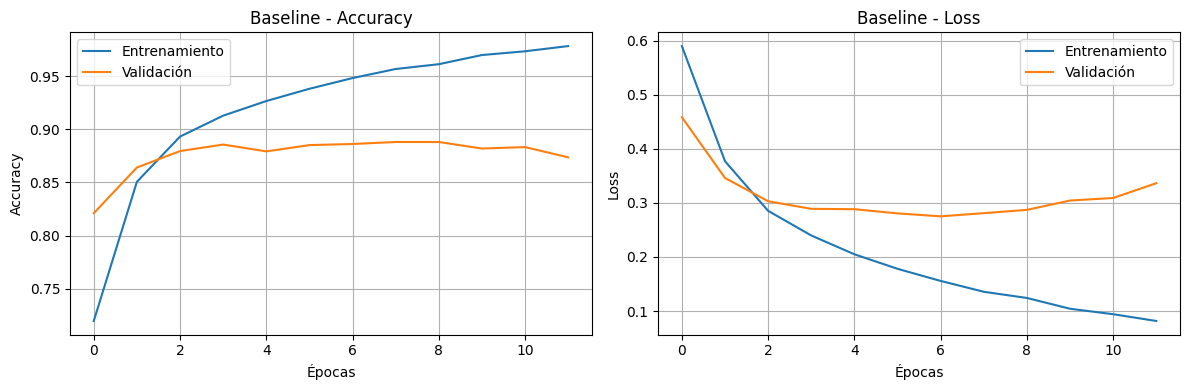

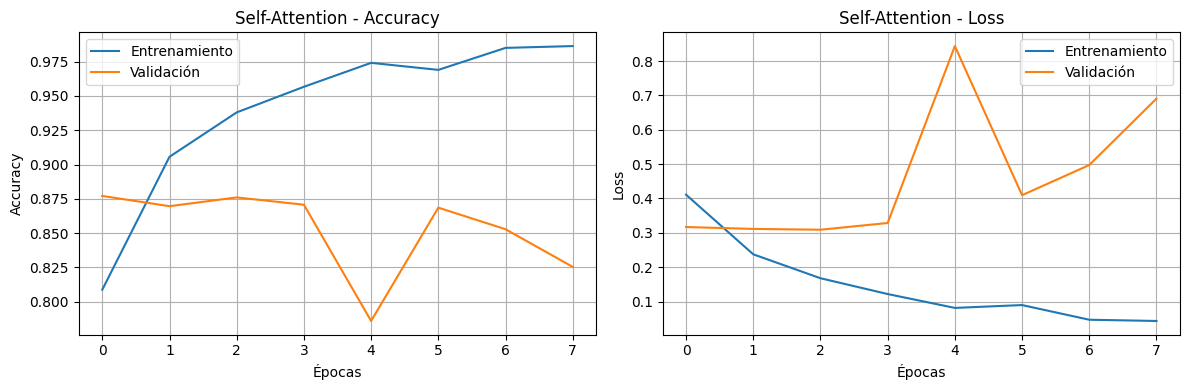

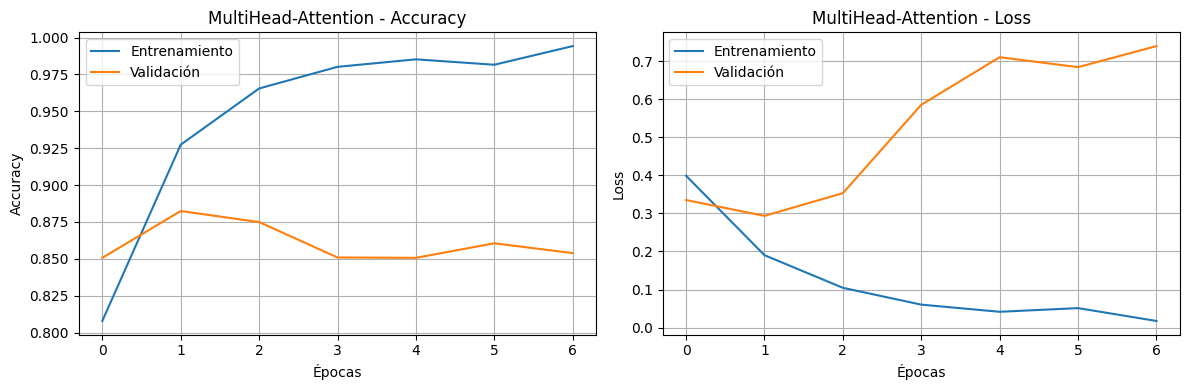


=== Comparativa Final ===
                       Modelo  Test Accuracy  Test Loss
                     Baseline        0.88016   0.295438
      Transformer (Attention)        0.86920   0.309721
     Transformer (Multi-Head)        0.86740   0.318719
Transformer (Self-Attn block)        0.86300   0.342677


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd

# 🔧 Configurar GPU para asignar memoria de forma dinámica
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"✅ Memoria de GPU configurada para crecimiento dinámico {gpu}.")
    except RuntimeError as e:
        print("❌ Error al configurar memoria de GPU:", e)


VOCAB_SIZE = 20000 # Número máximo de palabras del vocabulario
MAX_LEN = 200 # Longitud fija de cada secuencia
EMB_DIM = 128
BATCH   = 64

# Carga del dataset IMDB
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")

# split de validación
VAL_SPLIT = 0.15
n_val = int(len(x_train) * VAL_SPLIT)
x_val, y_val = x_train[:n_val], y_train[:n_val]
x_trn, y_trn = x_train[n_val:], y_train[n_val:]

print(f"Tamaño entrenamiento: {x_trn.shape}, Validación: {x_val.shape}, Test: {x_test.shape}")


class PositionalEmbedding(layers.Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token = layers.Embedding(vocab_size, embed_dim)
        self.pos   = layers.Embedding(max_len, embed_dim)
        self.max_len = max_len
    def call(self, x):
        positions = tf.range(0, self.max_len)
        return self.token(x) + self.pos(positions)

# Baseline (rápido)
def build_baseline():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = layers.Embedding(VOCAB_SIZE, EMB_DIM)(inp)
    x = layers.GlobalAveragePooling1D()(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile("adam", "binary_crossentropy", metrics=["accuracy"])
    return m

# Transformer simple (solo atención o MHA)
def build_transformer():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)

    x = layers.Attention()([x, x])   #Self-att
# x = layers.MultiHeadAttention(num_heads=4, key_dim=EMB_DIM//4)(x, x)   # MultiHA

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(keras.optimizers.Adam(1e-3), "binary_crossentropy", metrics=["accuracy"])
    return m

baseline = build_baseline()
tx = build_transformer()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Baseline model training: ")

hist_base = baseline.fit(x_trn, y_trn, validation_data=(x_val, y_val),
                         epochs=30, batch_size=BATCH, callbacks=[early_stop], verbose=2)

print("Attention model training: ")
hist_tx   = tx.fit(x_trn, y_trn, validation_data=(x_val, y_val),
                   epochs=30, batch_size=BATCH, callbacks=[early_stop], verbose=2)

test_base = baseline.evaluate(x_test, y_test, verbose=0)
test_tx   = tx.evaluate(x_test, y_test, verbose=0)
print(f"\nBaseline  Test acc: {test_base[1]:.4f}")
print(f"Attention Test acc: {test_tx[1]:.4f}")


# función para graficar accuracy y loss
def plot_training_curves(hist, title):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    axs[0].plot(hist.history['accuracy'], label='Entrenamiento')
    axs[0].plot(hist.history['val_accuracy'], label='Validación')
    axs[0].set_title(f'{title} - Accuracy')
    axs[0].set_xlabel('Épocas')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()
    axs[0].grid()

    # Loss
    axs[1].plot(hist.history['loss'], label='Entrenamiento')
    axs[1].plot(hist.history['val_loss'], label='Validación')
    axs[1].set_title(f'{title} - Loss')
    axs[1].set_xlabel('Épocas')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

# -------------------------
# Bloque Transformer (self-attn simple ó multi-head)
# -------------------------
def transformer_block(x, use_multihead=True):
    # x: (batch, seq_len, EMB_DIM)
    if use_multihead:
        attn_out = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=EMB_DIM // 4
        )(x, x)  # self-attention
    else:
        # Self-attention simple con una sola "cabeza"
        attn_out = layers.Attention()([x, x])  # (batch, seq_len, EMB_DIM)

    # Residual + LayerNorm
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Pequeño feed-forward
    ff = layers.Dense(EMB_DIM * 2, activation="relu")(x)
    ff = layers.Dense(EMB_DIM)(ff)

    # Otro residual + LayerNorm
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

# -------------------------
# Transformer con self-attention simple (sin MultiHead)
# -------------------------
def build_transformer_selfatt():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)
    x = transformer_block(x, use_multihead=False)   # self-attention
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# -------------------------
# Transformer con MultiHeadAttention
# -------------------------
def build_transformer_mha():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)
    x = transformer_block(x, use_multihead=True)    # multi-head attention
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# -------------------------
# Entrenamiento de los 2 modelos
# -------------------------
selfatt_tx = build_transformer_selfatt()
mha_tx     = build_transformer_mha()

print("\n=== Entrenando Transformer (Self-Attention) ===")
hist_self = selfatt_tx.fit(
    x_trn, y_trn,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=BATCH,
    callbacks=[early_stop],
    verbose=2
)

print("\n=== Entrenando Transformer (MultiHeadAttention) ===")
hist_mha = mha_tx.fit(
    x_trn, y_trn,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=BATCH,
    callbacks=[early_stop],
    verbose=2
)

# -------------------------
# Evaluación
# -------------------------
test_self = selfatt_tx.evaluate(x_test, y_test, verbose=0)
test_mha  = mha_tx.evaluate(x_test, y_test, verbose=0)

print("\n=== RESULTADOS EN TEST ===")
print(f"Transformer Self-Attn    -> acc: {test_self[1]:.4f}")
print(f"Transformer Multi-Head   -> acc: {test_mha[1]:.4f}")


plot_training_curves(hist_base, "Baseline")
plot_training_curves(hist_self, "Self-Attention")
plot_training_curves(hist_mha, "MultiHead-Attention")


# Crear tabla con métricas finales
resultados = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Transformer (Attention)",
        "Transformer (Self-Attn block)",
        "Transformer (Multi-Head)"
    ],
    "Test Accuracy": [
        test_base[1],
        test_tx[1],
        test_self[1],
        test_mha[1]
    ],
    "Test Loss": [
        test_base[0],
        test_tx[0],
        test_self[0],
        test_mha[0]
    ]
})

# Mostrar la tabla ordenada por Test Accuracy
print("\n=== Comparativa Final ===")
print(resultados.sort_values("Test Accuracy", ascending=False).to_string(index=False))